In [1]:
import SimpleITK as sitk
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import torch
from monai.transforms import (
    Compose, 
    LoadImaged, 
    EnsureChannelFirstd, 
    RandSpatialCropd, 
    RandFlipd, 
    RandRotate90d, 
    ToTensord,
    RandShiftIntensityd
)
from monai.networks.nets import UNet
from monai.losses import DiceCELoss  # <--- Esta es la pérdida combinada
from monai.data import Dataset, DataLoader, decollate_batch

import glob
from sklearn.model_selection import train_test_split

import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from monai.data import decollate_batch
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference

para monai hay q hacer pip install monai[itk]  

Lógica de conversión:Si $L$ es tu volumen de etiquetas original:$$L_{binary} = \begin{cases} 1 & \text{si } L > 0 \\ 0 & \text{si } L = 0 \end{cases}$$

In [ ]:
def binarize_mha(input_path, output_path):
    # Cargar imagen .mha
    itk_img = sitk.ReadImage(input_path)
    img_array = sitk.GetArrayFromImage(itk_img)
    
    # Binarizar: cualquier valor > 0 se convierte en 1
    binary_array = (img_array > 0).astype(np.uint8)
    
    # Convertir de nuevo a objeto ITK para preservar metadatos (spacing, origin)
    binary_img = sitk.GetImageFromArray(binary_array)
    binary_img.CopyInformation(itk_img)
    
    sitk.WriteImage(binary_img, output_path)

In [ ]:
script_dir = Path.cwd()

# Construimos las rutas a partir de ahí
input_folder = script_dir / "Data" / "PENGWIN_CT_train_labels"
output_folder = script_dir / "Data" / "PENGWIN_CT_train_labels_binary"

# Crear la carpeta de salida si no existe
output_folder.mkdir(parents=True, exist_ok=True)

# Obtener lista de archivos .mha
files = list(input_folder.glob("*.mha"))

if not files:
    print(f"No se encontraron archivos en: {input_folder}")
else:
    print(f"Procesando desde: {input_folder}")
    
    # Loop con barra de progreso
    for file_path in tqdm(files, desc="Binarizando etiquetas", unit="vol"):
        target_file = output_folder / file_path.name
        
        try:
            binarize_mha(file_path, target_file)
        except Exception as e:
            print(f"\nError en {file_path.name}: {e}")

    print(f"\n¡Listo! Etiquetas binarizadas guardadas en: {output_folder}")

Ahora procesamso las imagenes, nos quedamos con las intensidades de los huesos (clipping de intensidades y normalizamos)


Enfoque en Densidad Ósea: 
- En la escala Hounsfield, el hueso suele empezar por encima de los 200-300 HU. Al poner el techo en 1000 HU, capturamos desde hueso esponjoso hasta cortical densa. El suelo en 50 HU ayuda a que el modelo distinga el borde entre tejido blando y hueso.

- Estabilidad del Gradiente: Las redes neuronales convergen mucho más rápido cuando los datos de entrada están en un rango pequeño (como $0$ a $1$) en lugar de valores de miles.

- Consistencia: Al aplicar el mismo clipping a todos los pacientes de distintas instituciones, eliminas variaciones de brillo/contraste que podrían confundir al modelo.

In [11]:
def process_ct_image(input_path, output_path, min_hu=50, max_hu=1000):
    # 1. Cargar imagen .mha
    itk_img = sitk.ReadImage(str(input_path))
    img_array = sitk.GetArrayFromImage(itk_img).astype(np.float32)
    
    # 2. Clipping: Limitar valores al rango de interés (hueso)
    # Todo lo menor a -100 será -100, todo lo mayor a 1000 será 1000
    img_array = np.clip(img_array, min_hu, max_hu)
    
    # 3. Normalización Min-Max: Escalar al rango [0, 1]
    # Fórmula: (x - min) / (max - min)
    img_array = (img_array - min_hu) / (max_hu - min_hu)
    
    # 4. Guardar manteniendo metadatos originales
    processed_img = sitk.GetImageFromArray(img_array)
    processed_img.CopyInformation(itk_img)
    sitk.WriteImage(processed_img, str(output_path))

In [12]:
script_dir = Path.cwd()

# AJUSTA ESTO: Ruta de tus imágenes de entrenamiento originales
input_folder_images = script_dir / "Data" / "PENGWIN_CT_train_images_part1" 
output_folder_images = script_dir / "Data" / "PENGWIN_CT_train_images_normalized"

# Crear carpeta de salida
output_folder_images.mkdir(parents=True, exist_ok=True)

# Obtener lista de archivos
image_files = list(input_folder_images.glob("*.mha"))

if not image_files:
    print(f"No se encontraron imágenes en: {input_folder_images}")
else:
    print(f"Procesando {len(image_files)} imágenes CT...")
    
    for img_path in tqdm(image_files, desc="Normalizando CTs", unit="vol"):
        target_path = output_folder_images / img_path.name
        
        try:
            process_ct_image(img_path, target_path)
        except Exception as e:
            print(f"\nError en {img_path.name}: {e}")

    print(f"\n¡Listo! Imágenes normalizadas en: {output_folder_images}")

Procesando 100 imágenes CT...


Normalizando CTs: 100%|██████████| 100/100 [01:26<00:00,  1.16vol/s]


¡Listo! Imágenes normalizadas en: c:\Users\mosca\Documents\Maestria\Segundo\Primer_cuatri\Visualization\Vis_per_comp\Data\PENGWIN_CT_train_images_normalized


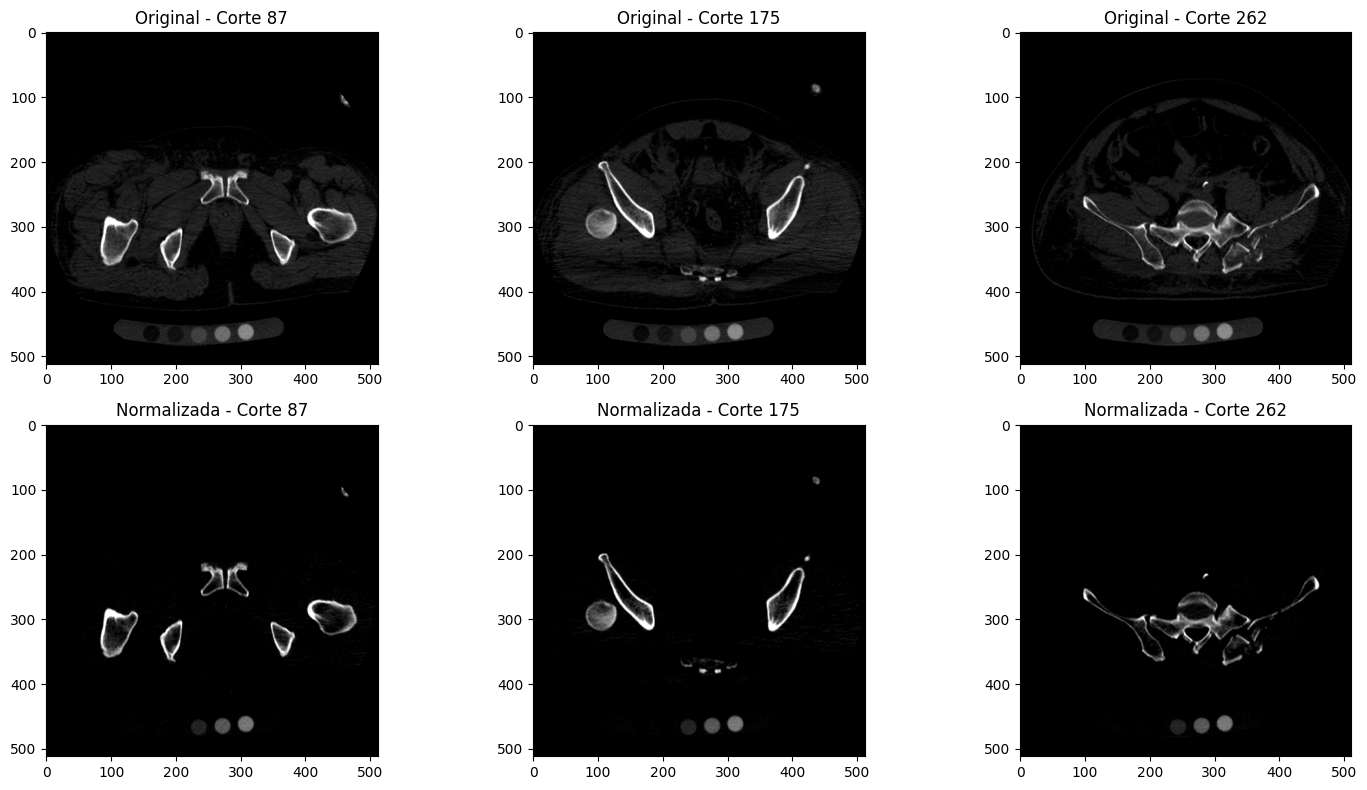

In [14]:

script_dir = Path.cwd()
input_folder_images = script_dir / "Data" / "PENGWIN_CT_train_images_part1" 
output_folder_images = script_dir / "Data" / "PENGWIN_CT_train_images_normalized"

# Listar archivos disponibles (usamos los nombres de la carpeta de salida)
files = sorted([f.name for f in output_folder_images.glob("*.mha")])

def check_manual(paciente_idx):
    file_name = files[paciente_idx]
    path_in = input_folder_images / file_name
    path_out = output_folder_images / file_name
    
    img_in = sitk.GetArrayFromImage(sitk.ReadImage(str(path_in)))
    img_out = sitk.GetArrayFromImage(sitk.ReadImage(str(path_out)))
    
    # Tomamos 3 cortes representativos
    slices = [int(len(img_in)*0.25), int(len(img_in)*0.5), int(len(img_in)*0.75)]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, s in enumerate(slices):
        axes[0, i].imshow(img_in[s], cmap='gray', vmin=-100, vmax=1000)
        axes[0, i].set_title(f"Original - Corte {s}")
        axes[1, i].imshow(img_out[s], cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f"Normalizada - Corte {s}")
    plt.tight_layout()
    plt.show()

# Cambia el número (0, 1, 2...) para ver distintos pacientes
check_manual(20)

Entrenamiento sin data augmentation

In [15]:


# 1. Definir Transformaciones para 3D
# He agregado RandShiftIntensityd para que el modelo sea más robusto a variaciones de brillo
train_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=True), # <--- Cambiado a True
    EnsureChannelFirstd(keys=["image", "label"]),
    
    # Recorte aleatorio 3D (ajusta roi_size según tu VRAM)
    RandSpatialCropd(
        keys=["image", "label"], 
        roi_size=[128, 128, 128], 
        random_center=True, 
        random_size=False
    ),
    
    # Aumentos de datos básicos
    # RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    # RandRotate90d(keys=["image", "label"], prob=0.5, spatial_axes=(0, 1)),
    # RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    
    ToTensord(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=True),
    EnsureChannelFirstd(keys=["image", "label"]),
    # Nota: No usamos RandSpatialCropd aquí para validar sobre el volumen completo 
    # o podrías usar CenterSpatialCropd si el volumen es muy grande.
    ToTensord(keys=["image", "label"]),
])

# 2. Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Definir el Modelo UNet 3D
model = UNet(
    spatial_dims=3,          
    in_channels=1,
    out_channels=1,         # Binario: Hueso (1) vs Fondo (0)
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

# 4. Definir la Función de Pérdida COMBINADA
# sigmoid=True aplica la activación necesaria para salida binaria automáticamente
loss_function = DiceCELoss(sigmoid=True)

# 5. Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"Modelo configurado en: {device}")

Modelo configurado en: cuda


In [16]:
# 1. Configuración de Rutas (Usando strings planos para máxima compatibilidad)
script_dir = Path.cwd()
images_dir = script_dir / "Data" / "PENGWIN_CT_train_images_normalized"
labels_dir = script_dir / "Data" / "PENGWIN_CT_train_labels_binary"

# Convertimos a string y usamos sorted para asegurar emparejamiento
images = sorted([str(p) for p in images_dir.glob("*.mha")])
labels = sorted([str(p) for p in labels_dir.glob("*.mha")])

if len(images) == 0:
    raise FileNotFoundError(f"No se encontraron imágenes en {images_dir}")

data_dicts = [{"image": i, "label": l} for i, l in zip(images, labels)]
train_files, val_files = train_test_split(data_dicts, test_size=0.2, random_state=42)


# 3. Datasets y Loaders (IMPORTANTE: num_workers=0 para Windows)
train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)
# num_workers=0 es más lento pero evita el RuntimeError en Windows/Notebooks
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=0)

# --- Verificación de seguridad ---
print("Intentando cargar el primer batch...")
try:
    check_data = next(iter(train_loader))
    print(f"¡Éxito! Shape imagen: {check_data['image'].shape}")
except Exception as e:
    print(f"Error detectado: {e}")
    # Si falla aquí, imprimiremos la primera ruta para ver si es correcta
    print(f"Revisando primera ruta: {data_dicts[0]['image']}")


try:
    check_val = next(iter(val_loader))
    print(f"¡Éxito! Shape de validación: {check_val['image'].shape}")
except Exception as e:
    print(f"Error en val_loader: {e}")

Intentando cargar el primer batch...
¡Éxito! Shape imagen: torch.Size([1, 1, 128, 128, 128])
¡Éxito! Shape de validación: torch.Size([1, 1, 512, 512, 268])


Iniciando entrenamiento con DiceCELoss en: cuda


Epoch 2/50: 100%|██████████| 80/80 [02:52<00:00,  2.15s/it, loss=1.3709]


¡Nuevo récord! Menor Loss de Validación: 1.6482


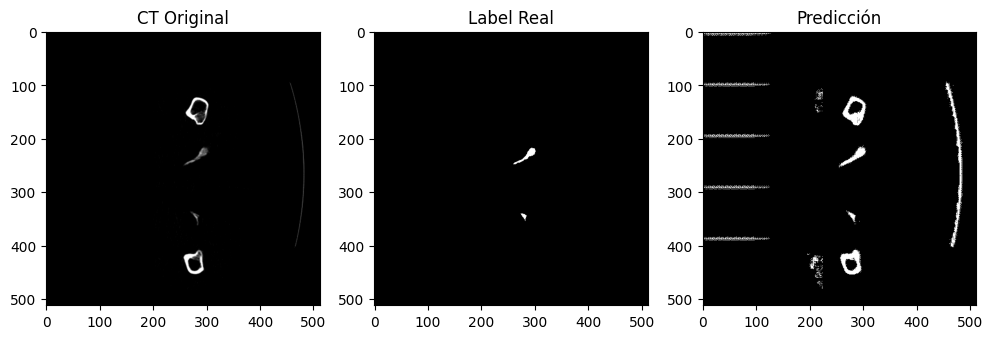

Epoch 4/50: 100%|██████████| 80/80 [02:59<00:00,  2.25s/it, loss=1.7445]


¡Nuevo récord! Menor Loss de Validación: 1.6332


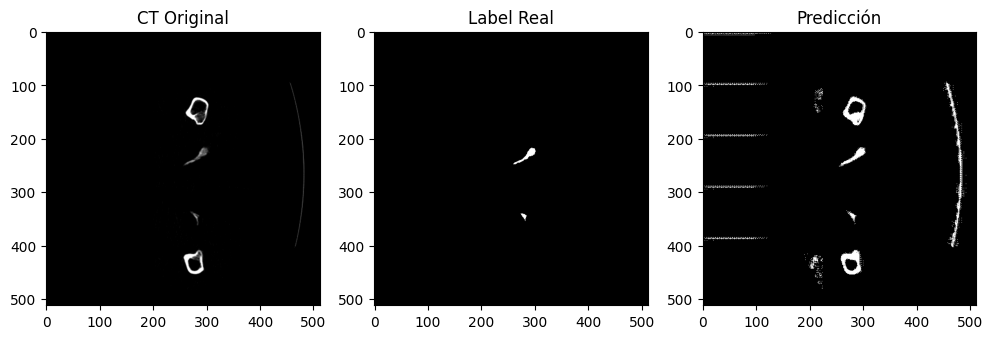

Epoch 6/50: 100%|██████████| 80/80 [15:43:41<00:00, 707.76s/it, loss=1.4799]      


¡Nuevo récord! Menor Loss de Validación: 1.6243


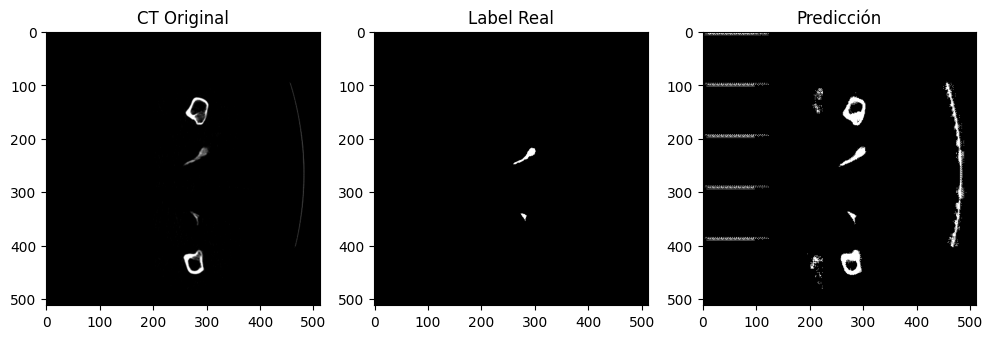

Epoch 8/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=1.7512]


¡Nuevo récord! Menor Loss de Validación: 1.6129


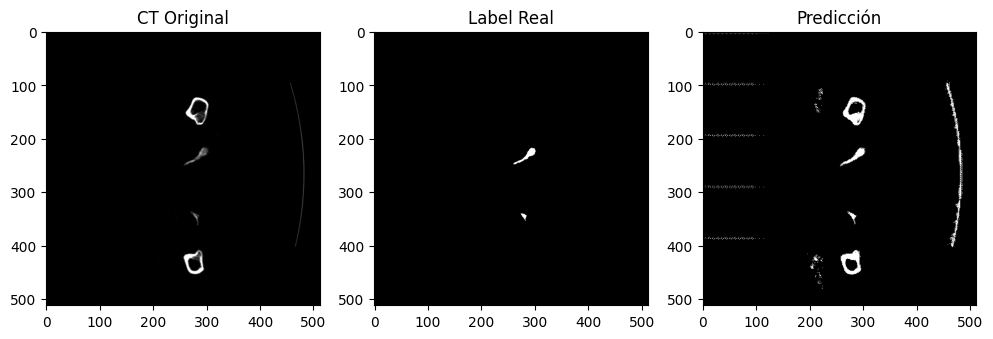

Epoch 10/50: 100%|██████████| 80/80 [02:50<00:00,  2.14s/it, loss=1.7820]


¡Nuevo récord! Menor Loss de Validación: 1.6002


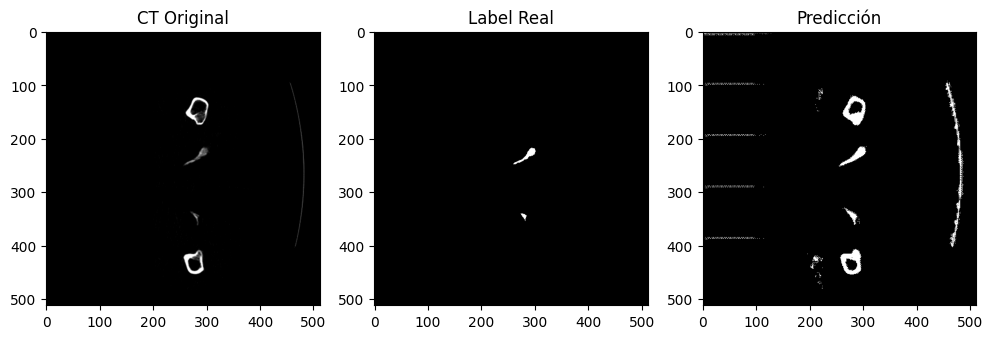

Epoch 12/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=1.3291]


¡Nuevo récord! Menor Loss de Validación: 1.5922


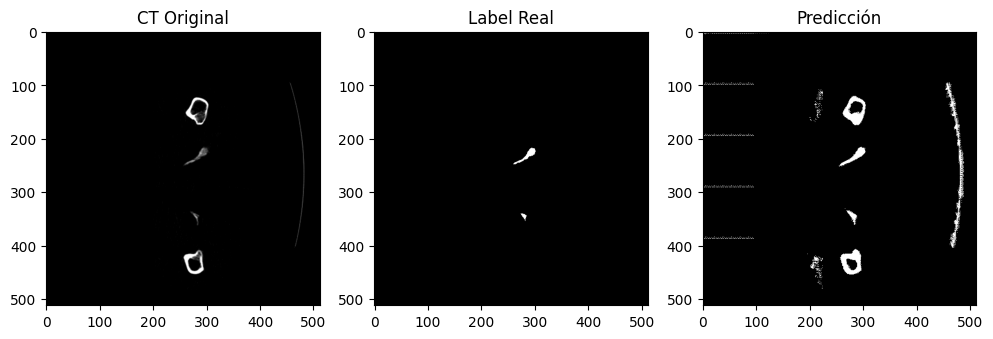

Epoch 14/50: 100%|██████████| 80/80 [02:49<00:00,  2.12s/it, loss=1.5800]


¡Nuevo récord! Menor Loss de Validación: 1.5783


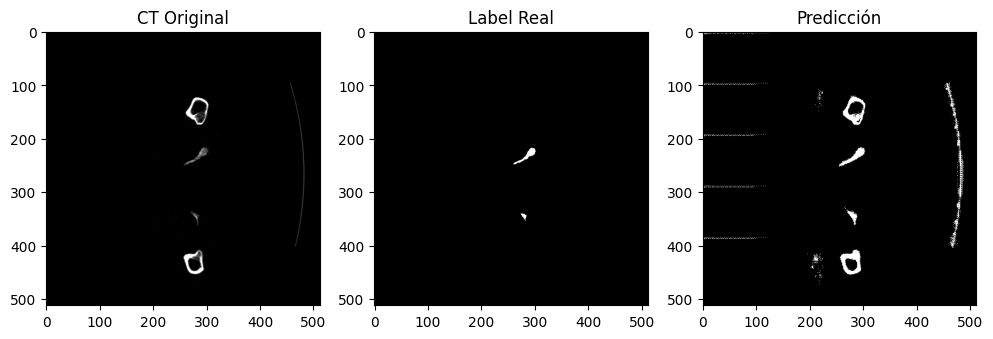

Epoch 16/50: 100%|██████████| 80/80 [02:50<00:00,  2.13s/it, loss=1.2844]


¡Nuevo récord! Menor Loss de Validación: 1.5672


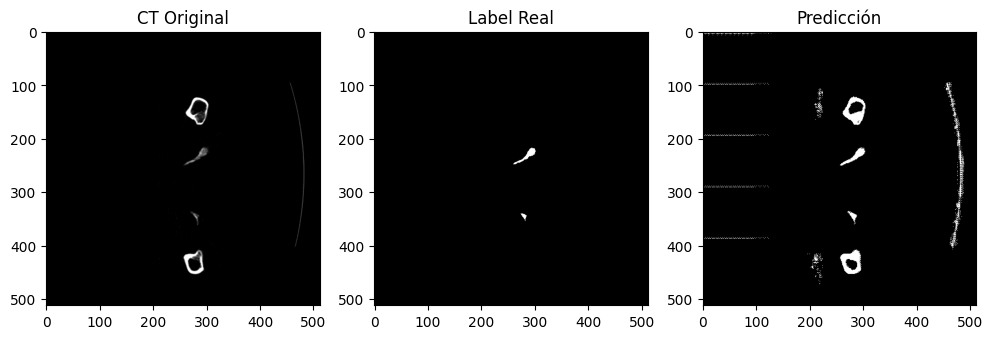

Epoch 18/50: 100%|██████████| 80/80 [02:50<00:00,  2.13s/it, loss=1.2201]


¡Nuevo récord! Menor Loss de Validación: 1.5557


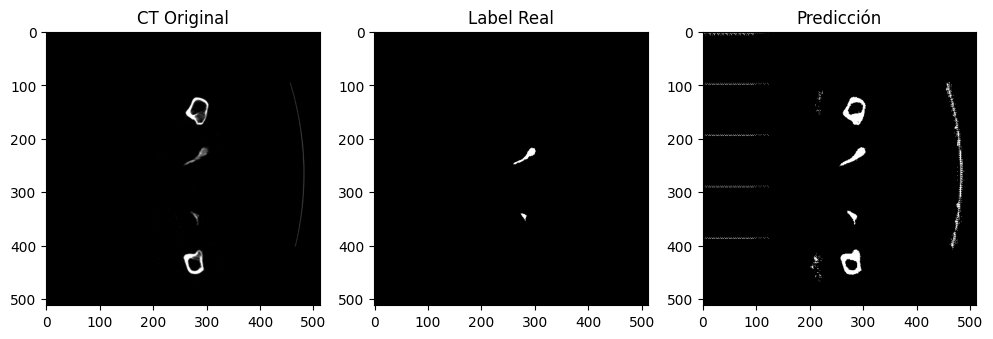

Epoch 20/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=1.4650]


¡Nuevo récord! Menor Loss de Validación: 1.5488


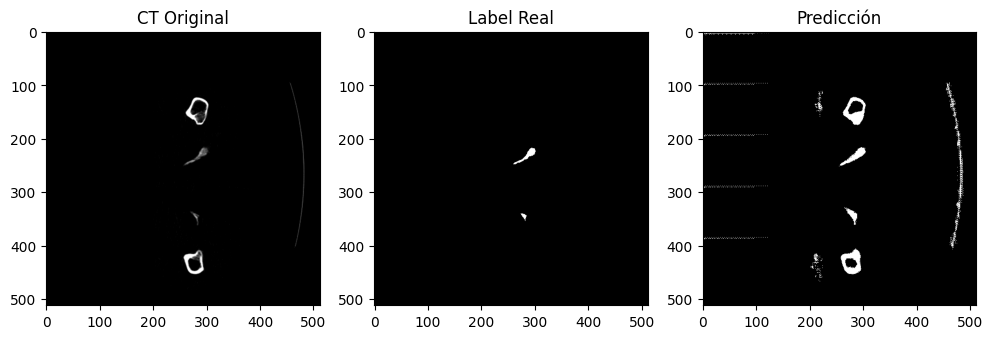

Epoch 22/50: 100%|██████████| 80/80 [02:49<00:00,  2.11s/it, loss=1.1323]


¡Nuevo récord! Menor Loss de Validación: 1.5363


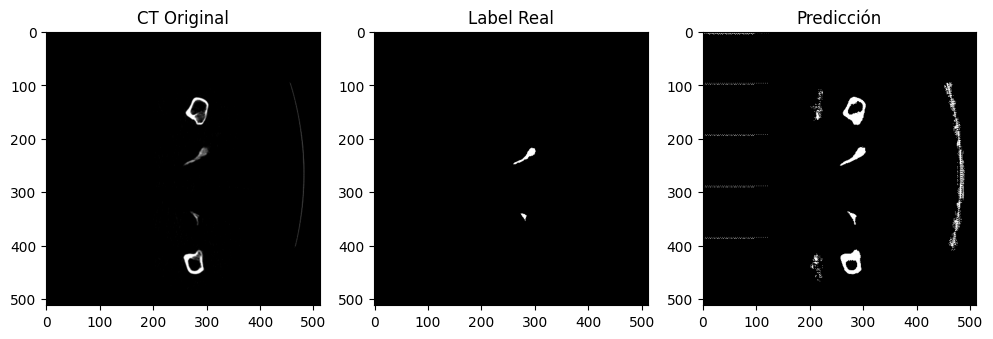

Epoch 24/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=1.1497]


¡Nuevo récord! Menor Loss de Validación: 1.5268


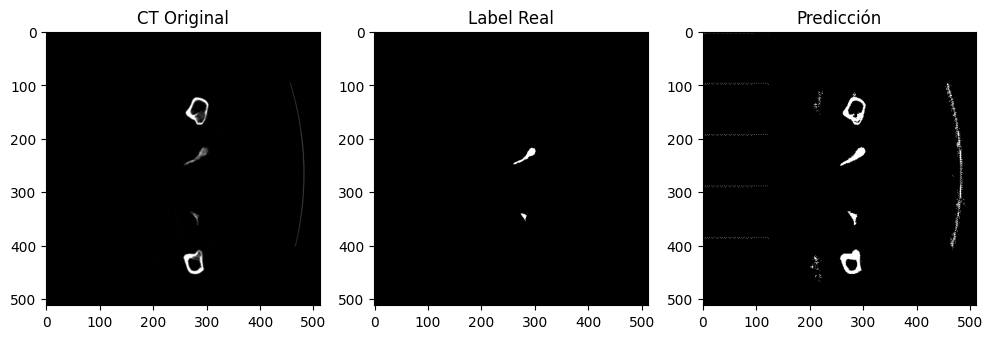

Epoch 26/50: 100%|██████████| 80/80 [02:49<00:00,  2.12s/it, loss=1.4857]


¡Nuevo récord! Menor Loss de Validación: 1.5170


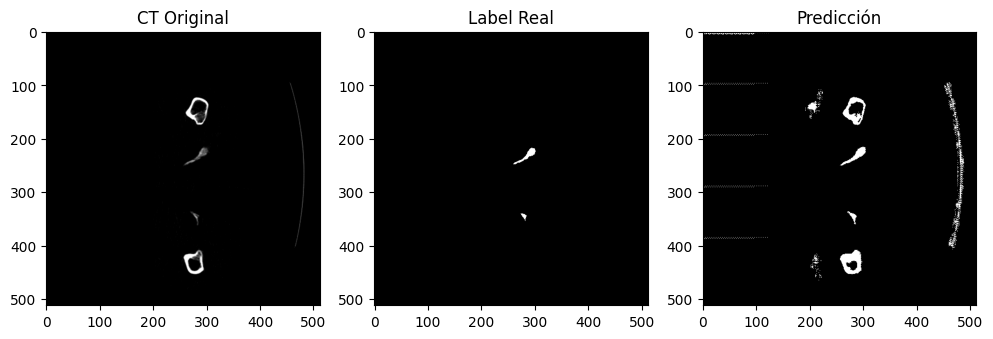

Epoch 28/50: 100%|██████████| 80/80 [02:50<00:00,  2.13s/it, loss=1.4581]


¡Nuevo récord! Menor Loss de Validación: 1.5009


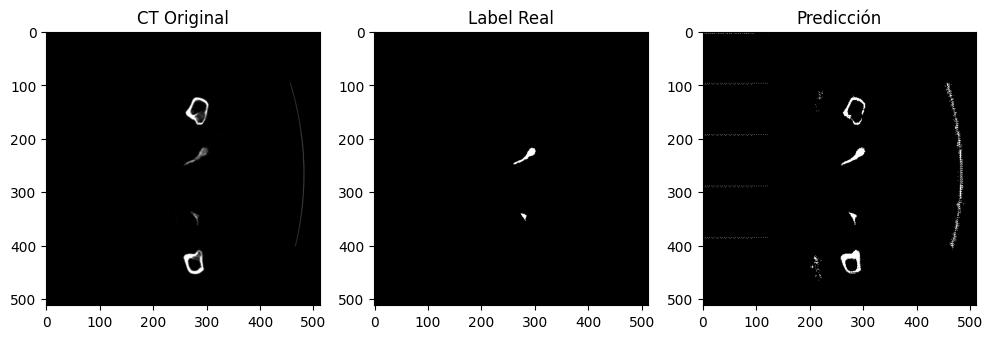

Epoch 30/50: 100%|██████████| 80/80 [02:50<00:00,  2.14s/it, loss=1.5376]


¡Nuevo récord! Menor Loss de Validación: 1.4954


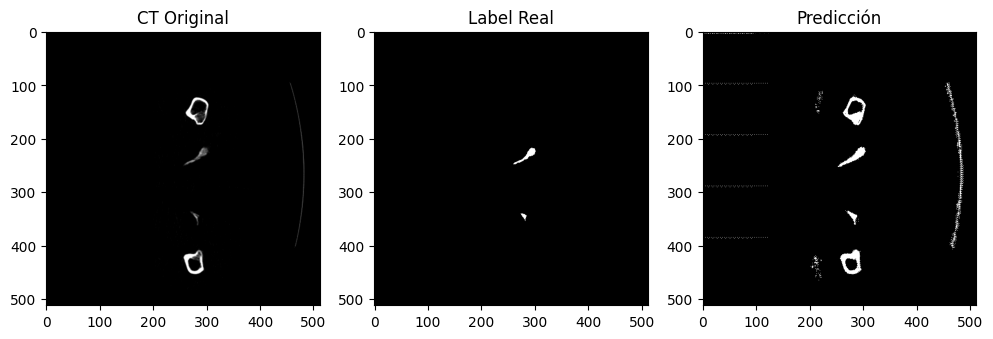

Epoch 32/50: 100%|██████████| 80/80 [02:50<00:00,  2.13s/it, loss=1.0802]


¡Nuevo récord! Menor Loss de Validación: 1.4793


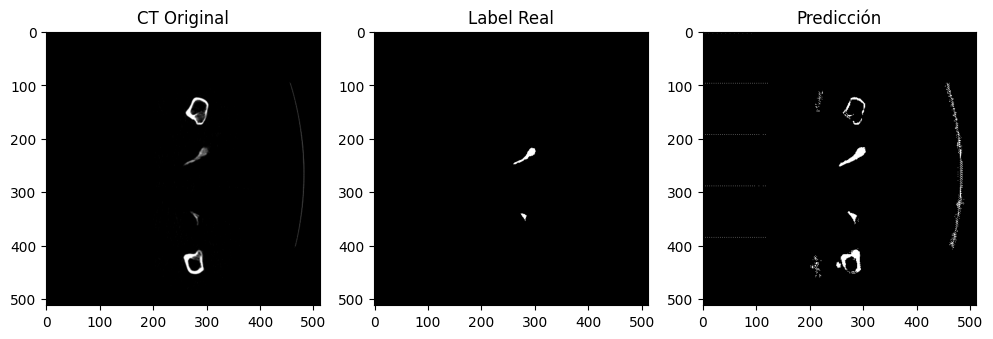

Epoch 34/50: 100%|██████████| 80/80 [02:50<00:00,  2.14s/it, loss=1.1742]


¡Nuevo récord! Menor Loss de Validación: 1.4668


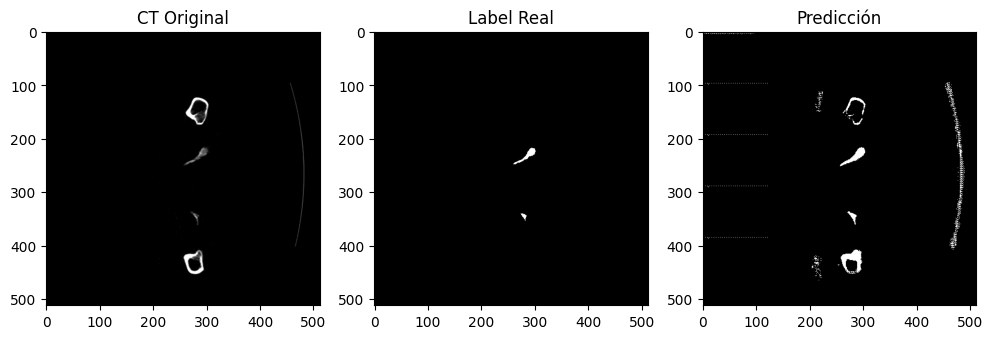

Epoch 36/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=1.1136]


¡Nuevo récord! Menor Loss de Validación: 1.4601


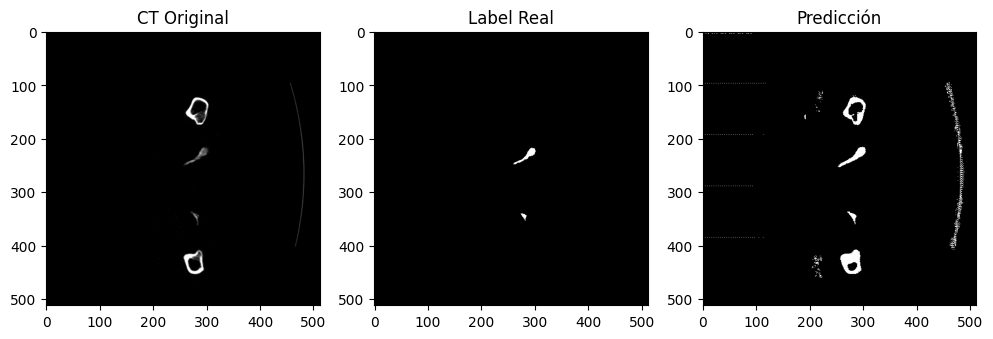

Epoch 38/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=0.6828]


¡Nuevo récord! Menor Loss de Validación: 1.4446


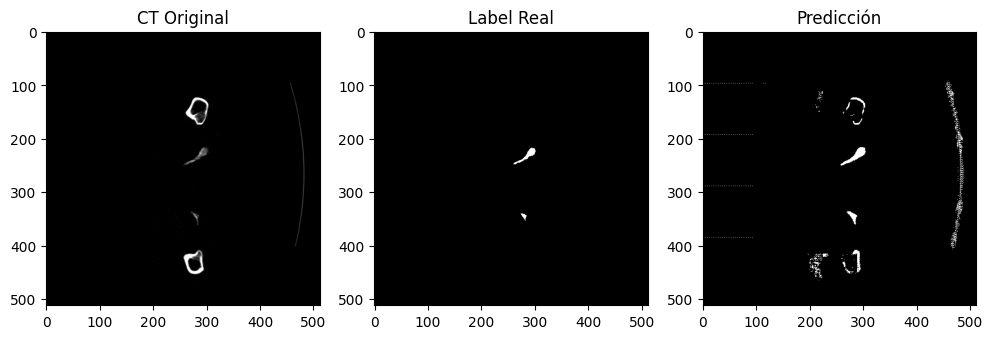

Epoch 40/50: 100%|██████████| 80/80 [02:51<00:00,  2.14s/it, loss=1.4875]


¡Nuevo récord! Menor Loss de Validación: 1.4305


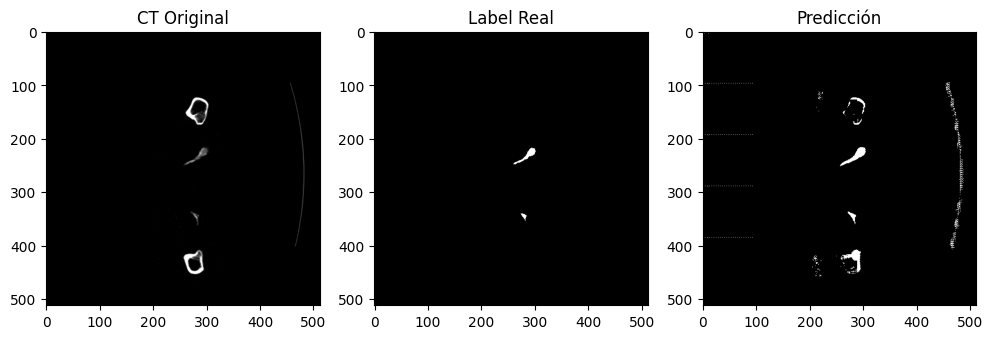

Epoch 42/50: 100%|██████████| 80/80 [02:51<00:00,  2.15s/it, loss=0.9838]


¡Nuevo récord! Menor Loss de Validación: 1.4272


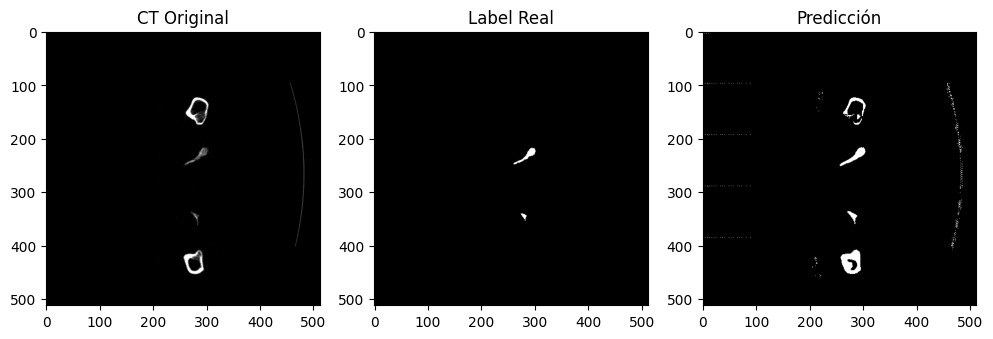

Epoch 44/50: 100%|██████████| 80/80 [02:50<00:00,  2.13s/it, loss=0.8266]


¡Nuevo récord! Menor Loss de Validación: 1.4154


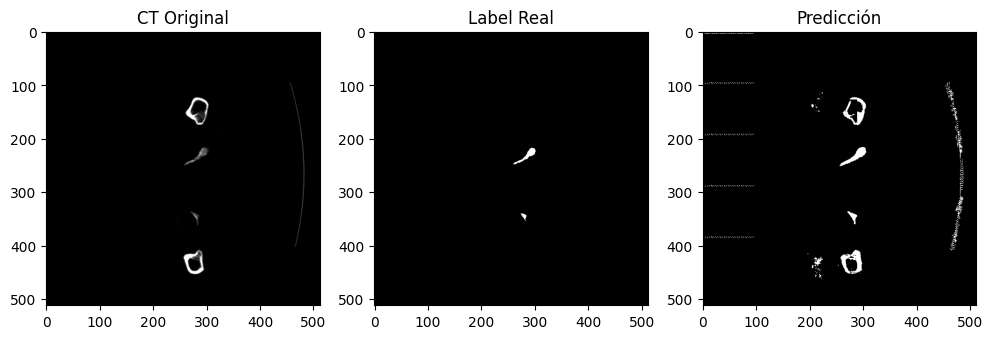

Epoch 46/50: 100%|██████████| 80/80 [02:46<00:00,  2.08s/it, loss=1.5353]


¡Nuevo récord! Menor Loss de Validación: 1.4012


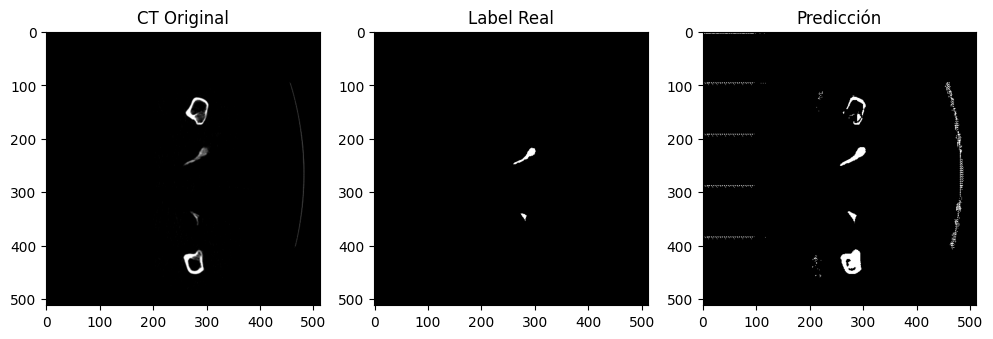

Epoch 48/50: 100%|██████████| 80/80 [02:46<00:00,  2.08s/it, loss=0.7788]


¡Nuevo récord! Menor Loss de Validación: 1.3778


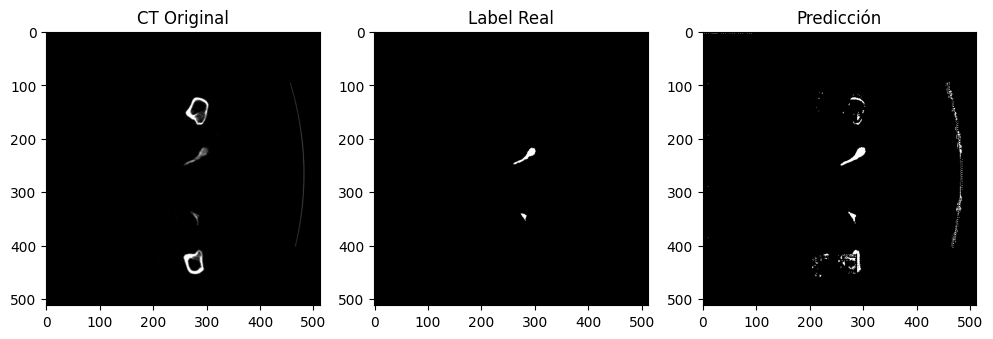

Epoch 50/50: 100%|██████████| 80/80 [02:47<00:00,  2.09s/it, loss=1.6371]


¡Nuevo récord! Menor Loss de Validación: 1.3679


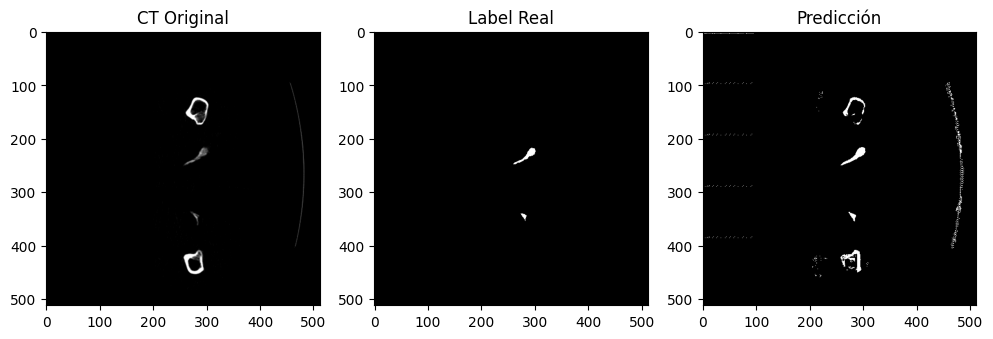

Entrenamiento terminado. Mejor Loss de Validación: 1.3679 en época 50


In [19]:


# 1. Configuración de Métricas
# Usamos DiceMetric para monitorear el progreso (solo el score Dice)
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)
post_label = AsDiscrete(threshold=0.5)

# 2. Parámetros de Control
max_epochs = 50
val_interval = 2
best_metric = -1
best_metric_epoch = -1
best_val_loss=10000000000000000

print(f"Iniciando entrenamiento con DiceCELoss en: {device}")

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    step = 0
    
    # --- LOOP DE ENTRENAMIENTO ---
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epochs}")
    for batch_data in train_pbar:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Aquí usamos la pérdida combinada que definimos (Dice + CE)
        loss = loss_function(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    
    epoch_loss /= step
    
    # --- FASE DE VALIDACIÓN ---
    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_epoch_loss = 0
        val_step = 0
        
        with torch.no_grad():
            for val_data in val_loader:
                val_step += 1
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                
                # Inferencia por ventana deslizante
                val_outputs = sliding_window_inference(
                    inputs=val_inputs, 
                    roi_size=(128, 128, 128), 
                    sw_batch_size=4, 
                    predictor=model
                )
                
                # Calculamos la LOSS de validación usando la misma función
                v_loss = loss_function(val_outputs, val_labels)
                val_epoch_loss += v_loss.item()
                
                # Para la visualización seguimos usando post-procesamiento
                val_outputs_vis = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels_vis = [post_label(i) for i in decollate_batch(val_labels)]

            val_epoch_loss /= val_step
            
            # --- LÓGICA DE GUARDADO POR MÍNIMA LOSS ---
            if val_epoch_loss < best_val_loss:
                best_val_loss = val_epoch_loss
                best_loss_epoch = epoch + 1
                torch.save(model.state_dict(), "best_pengwin_model_min_loss.pth")
                print(f"¡Nuevo récord! Menor Loss de Validación: {best_val_loss:.4f}")
            else:
                print(f"Loss Val: {val_epoch_loss:.4f} (Mejor: {best_val_loss:.4f})")

            # Visualización (Corte central)
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1); plt.title("CT Original"); plt.imshow(val_inputs[0, 0, :, :, 64].cpu(), cmap="gray")
            plt.subplot(1, 3, 2); plt.title("Label Real"); plt.imshow(val_labels_vis[0][0, :, :, 64].cpu(), cmap="bone")
            plt.subplot(1, 3, 3); plt.title("Predicción"); plt.imshow(val_outputs_vis[0][0, :, :, 64].cpu(), cmap="bone")
            plt.show()

print(f"Entrenamiento terminado. Mejor Loss de Validación: {best_val_loss:.4f} en época {best_loss_epoch}")

Vemos mas o menso q onda esto

Extrayendo superficies 3D... Esto puede tomar un momento.
Mostrando visualización...


Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.


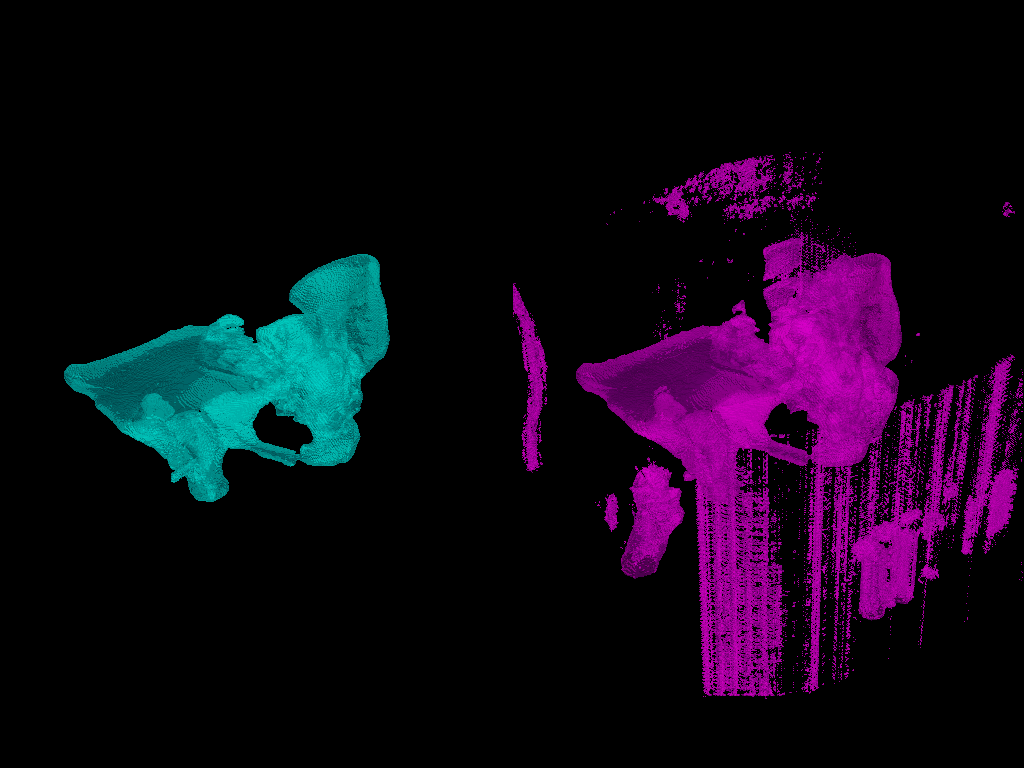

In [22]:
import pyvista as pv
from skimage import measure
import numpy as np
import torch
from monai.inferers import sliding_window_inference

def visualizar_comparativa_final(model, data_sample, device):
    # Ya no usamos set_plotter_backend para evitar el AttributeError
    model.eval()
    with torch.no_grad():
        inputs = data_sample["image"].to(device)
        labels = data_sample["label"].cpu().numpy()[0, 0]
        
        # Inferencia con ventana deslizante (ajustada al tamaño del entrenamiento)
        outputs = sliding_window_inference(inputs, (128, 128, 128), 4, model)
        # Aplicamos sigmoid y threshold para binarizar
        preds = (torch.sigmoid(outputs) > 0.8).cpu().numpy()[0, 0]

    def extraer_malla(volumen):
        # Verificamos si hay algún voxel positivo para evitar errores en marching_cubes
        if np.sum(volumen) == 0:
            return None
        # Generar superficie
        verts, faces, _, _ = measure.marching_cubes(volumen, level=0.5)
        # Formatear caras para PyVista (prefijo 3 para triángulos)
        faces_pv = np.hstack(np.c_[np.full(len(faces), 3), faces])
        return pv.PolyData(verts, faces_pv)

    print("Extrayendo superficies 3D... Esto puede tomar un momento.")
    malla_real = extraer_malla(labels)
    malla_pred = extraer_malla(preds)

    # Creamos el Plotter. 
    # notebook=True intenta usar el backend disponible para Jupyter automáticamente.
    plotter = pv.Plotter(shape=(1, 2), window_size=[1024, 768], notebook=True)
    
    # Subplot 0: Ground Truth (Cian)
    plotter.subplot(0, 0)
    plotter.add_text("GROUND TRUTH", font_size=10)
    if malla_real:
        plotter.add_mesh(malla_real, color="cyan", opacity=0.7, label="Real")
    else:
        plotter.add_text("Sin etiquetas detectadas", font_size=8, color="red")
    
    # Subplot 1: UNet Prediction (Magenta)
    plotter.subplot(0, 1)
    plotter.add_text("PREDICCIÓN UNET 3D", font_size=10)
    if malla_pred:
        # Suavizado ligero para mejorar la visualización estética
        malla_suave = malla_pred.smooth(n_iter=20)
        plotter.add_mesh(malla_suave, color="magenta", opacity=0.7, label="Predicción")
    else:
        plotter.add_text("Sin hueso detectado", font_size=8, color="red")

    plotter.link_views() # Rotación sincronizada
    plotter.background_color = "black"
    
    print("Mostrando visualización...")
    plotter.show()

# --- EJECUCIÓN ---
sample = next(iter(val_loader))
visualizar_comparativa_final(model, sample, device)

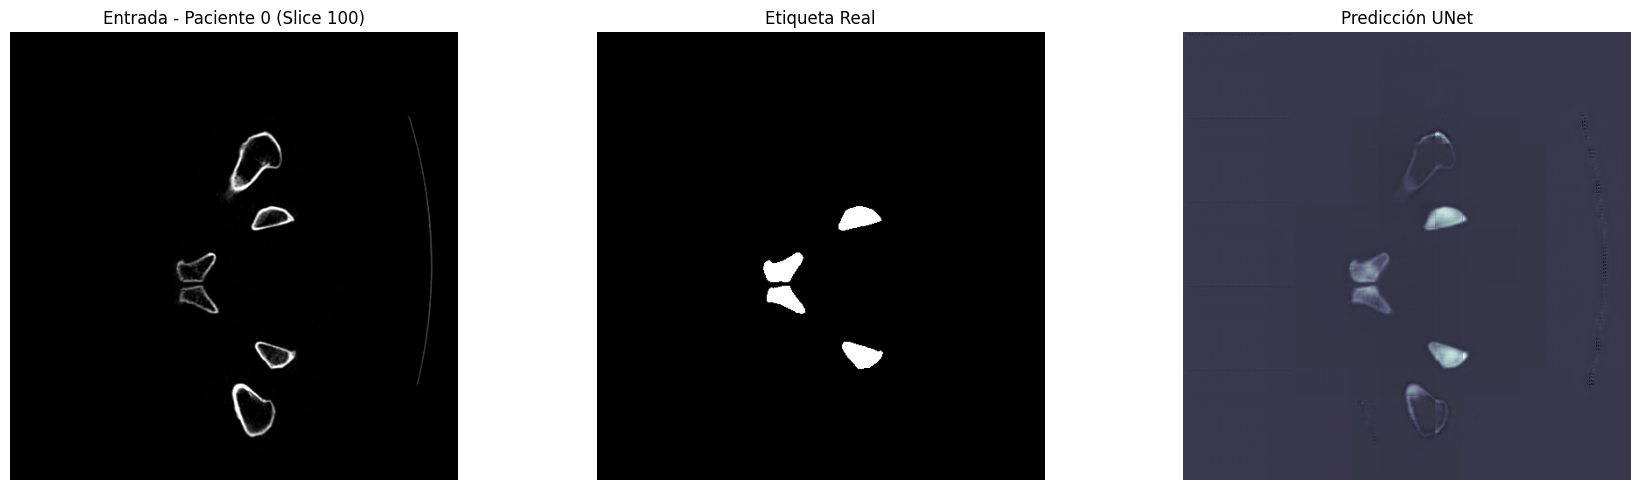

In [23]:
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
paciente_idx = 0  # ¡Ojo! Si tu batch es de 1, usa 0. 
corte_idx = 100    # El slice que quieres inspeccionar

plt.figure(figsize=(18, 5))

# 1. Imagen de entrada (Normalizada)
plt.subplot(1, 3, 1)
plt.title(f"Entrada - Paciente {paciente_idx} (Slice {corte_idx})")
plt.imshow(val_inputs[paciente_idx, 0, :, :, corte_idx].cpu(), cmap="gray")
plt.axis('off') # Opcional: quita los números de los ejes para que se vea más limpio

# 2. Etiqueta Real (Ground Truth)
plt.subplot(1, 3, 2)
plt.title("Etiqueta Real")
plt.imshow(val_labels[paciente_idx][0, :, :, corte_idx].cpu(), cmap="bone")
plt.axis('off')

# 3. Predicción UNet
plt.subplot(1, 3, 3)
plt.title("Predicción UNet")
# Usamos detach() por seguridad si viene de la red
pred=val_outputs[paciente_idx][0, :, :, corte_idx].detach().cpu()>0.8
plt.imshow(val_outputs[paciente_idx][0, :, :, corte_idx].detach().cpu(), cmap="bone")
plt.axis('off')

plt.tight_layout()
plt.show()